In [1]:
%pip install numpy
%pip install h5py
%pip install matplotlib
%pip install scipy

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
     ------ --------------------------------- 0.6/3.2 MB 17.5 MB/s eta 0:00:01
     ------------- -------------------------- 1.1/3.2 MB 14.0 MB/s eta 0:00:01
     -------------------- ------------------- 1.7/3.2 MB 13.2 MB/s eta 0:00:01
     --------------------------- ------------ 2.2/3.2 MB 12.9 MB/s eta 0:00:01
     ---------------------------------- ----- 2.8/3.2 MB 12.6 MB/s eta 0:00:01
     ---------------------------------------- 3.2/3.2 MB 11.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
     -- ------------------------------------- 0.5/8.2 MB 16.8 MB/s eta 0:00:01
     ---- ----------------------------------- 1.0/8.2 MB 12.5 MB/s eta 0:00:01
     ------- -------------------------------- 1.5/8.2 MB 13.8 MB/s eta 0:00:01
     ---------- ----------------------------- 2.1/8.2 MB 13.5 MB/s eta 0:00:01
     ------------- -------------------------- 2.7/8.2 MB 12.3 MB/s eta 0:00:01
     --------------- ------------------------ 3.3/8.2 MB 12.3 MB/s eta 0:00:01
     ----------------- ---------------------- 3.7/8.2 MB 12.4 MB/s eta 0:00:01
     -------------------- ------------------- 4.3/8.2 MB 11.8 MB/s eta 0:00:01
     ---------------------- ----------------- 4.7/8.2 MB 12.0 MB/s eta 0:00:01
     ------------------------- -------------- 5.3/8.2 MB 12.0 MB/s eta 0:00:01
     --------------------------- ------------ 5.7/8.2 MB 11.7 MB/s eta 0:00:01
     ------------------------------ --------- 6.2/8.2 MB 11.


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
      --------------------------------------- 0.6/41.3 MB 12.9 MB/s eta 0:00:04
     - -------------------------------------- 1.2/41.3 MB 12.3 MB/s eta 0:00:04
     - -------------------------------------- 1.7/41.3 MB 12.2 MB/s eta 0:00:04
     -- ------------------------------------- 2.3/41.3 MB 12.1 MB/s eta 0:00:04
     -- ------------------------------------- 2.8/41.3 MB 12.1 MB/s eta 0:00:04
     --- ------------------------------------ 3.4/41.3 MB 12.0 MB/s eta 0:00:04
     --- ------------------------------------ 4.0/41.3 MB 12.0 MB/s eta 0:00:04
     ---- ----------------------------------- 4.5/41.3 MB 12.1 MB/s eta 0:00:04
     ---- ----------------------------------- 5.1/41.3 MB 12.0 MB/s eta 0:00:04
     ----- ---------------------------------- 5.6/41.3 MB 12.0 MB/s eta 0:00:03
     ------ --------------------------------- 6.2/41.3 MB 12.0 MB/s eta 0:00:03
     ------ --------------------------------- 6.


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import h5py

file_path = r"C:\\Users\\qcrew\\Desktop\\Juncheng\\victoria\\data\\2026-06-04\\19-23-52_OutAndBackChi.hdf5"
#file_path = r"C:\\Users\\qcrew\\Desktop\\Juncheng\\victoria\\data\\2026-06-04\\18-05-45_OutAndBackChi.hdf5"

# r"C:\Users\qcrew2\Documents\Candace\eunice\data\2026-04-08\12-55-53_OutAndBackChi.hdf5"
# "C:\Users\qcrew2\Documents\Candace\eunice\data\2026-04-08\12-55-53_OutAndBackChi.hdf5"
# with h5py.File(file_path, "r") as f:
#     print(list(f.keys()))        # top-level groups/datasets

# latest_file =r"08-14-19_OUTANDBACK.hdf5"

# READ DATA
data = h5py.File(file_path, "r")

disp_phase = np.array(data["disp_phase"])
time_delays = np.array(data["time_delay"]) 

mean_intensity = np.mean(np.array(data["I"]), axis=0)

In [65]:
print(mean_intensity[:][1].shape)

(21,)


In [66]:
def gaussian(x, A, C, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + C

def line_fit(x, m, n):
    return m * x + n


In [67]:
# plt.plot(disp_phase, gaussian(disp_phase, 0.00016, -0.00016, 0.5, 0.05))

In [68]:
if 0:
    mu_list = []
    for i, delay in enumerate(time_delays):
        A_initial = np.max([mean_intensity[a][i] for a in range(len(mean_intensity))]) - np.min([mean_intensity[a][i] for a in range(len(mean_intensity))])
        C_initial = np.min([mean_intensity[a][i] for a in range(len(mean_intensity))])
        popt, pcov = curve_fit(gaussian, disp_phase, [mean_intensity[a][i] for a in range(len(mean_intensity))], p0=[A_initial, C_initial, 0.5, 0.05])
        A, C, mu, sigma = popt
        mu_list.append(mu)

    m_initial = np.max(mu_list) - np.min(mu_list)
    n_initial = np.min(mu_list)

    popt, pcov = curve_fit(line_fit, time_delays, mu_list, p0=[m_initial, n_initial])
    m, n = popt


In [69]:
max_list = []
for i in range(len(time_delays)):
    # print(i)
    max_list = np.max(mean_intensity, axis=1)
    # max_list.append(max)

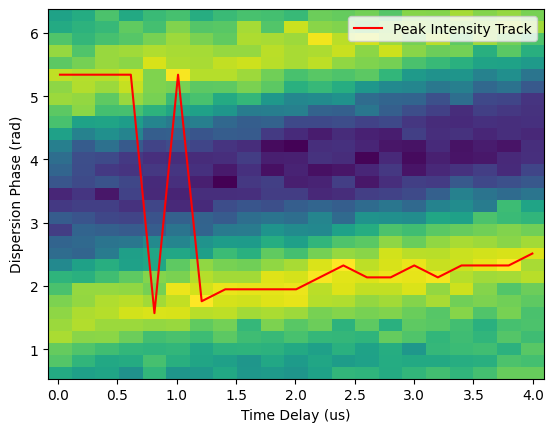

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Find the index of the max intensity for each time delay (along axis 0)
# This assumes mean_intensity has shape (len(disp_phase), len(time_delays))
max_indices = np.argmax(mean_intensity, axis=0)

# 2. Map those indices to the actual dispersion phase values
best_phases = disp_phase[max_indices] * 2 * np.pi

# 3. Plotting
plt.pcolormesh(time_delays / 1e3, disp_phase * 2 * np.pi, mean_intensity, shading='auto')

# Plot the tracked peak as a line or points
plt.plot(time_delays / 1e3, best_phases, 'r-', label="Peak Intensity Track")

plt.xlabel("Time Delay (us)")
plt.ylabel("Dispersion Phase (rad)")
plt.legend()
plt.show()

In [ ]:
# Assuming mean_intensity shape is (len(disp_phase), len(time_delays))
max_indices = np.argmax(mean_intensity, axis=0)

# # Convert indices to actual physical units (radians)
# x_data = time_delays / 1e3  # In microseconds
# y_data = disp_phase[max_indices] * 2 * np.pi  # In radians


# Convert indices to actual physical units (radians)
x_data = time_delays[6:] / 1e3  # In microseconds
y_data = disp_phase[max_indices][6:] * 2 * np.pi  # In radians

# m is the slope, n is the intercept
m, n = np.polyfit(x_data, y_data, 1)

# Generate the fit line for plotting
fit_line = m * x_data + n

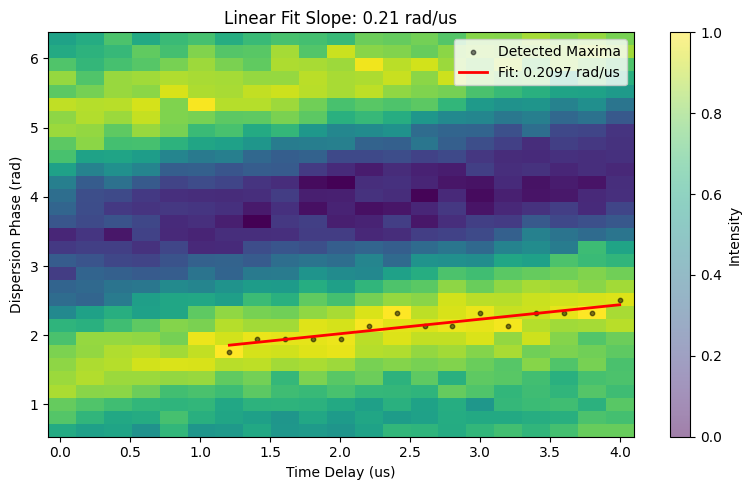

The extracted slope is: 0.2097402213880607 rad/us


In [82]:
plt.figure(figsize=(8, 5))

# Plot the heatmap
plt.pcolormesh(time_delays / 1e3, disp_phase * 2 * np.pi, mean_intensity, shading='auto')

# Plot the detected peaks (as points)
plt.scatter(x_data, y_data, color='black', s=10, label="Detected Maxima", alpha=0.5)

# Plot the linear fit
plt.plot(x_data, fit_line, color='red', linewidth=2, 
         label=f"Fit: {m:.4f} rad/us")

plt.xlabel("Time Delay (us)")
plt.ylabel("Dispersion Phase (rad)")
plt.title(f"Linear Fit Slope: {m:.2f} rad/us")
plt.legend()
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

print(f"The extracted slope is: {m} rad/us")

Slope: 0.2097 rad/us
Slope: 33.38 kHz


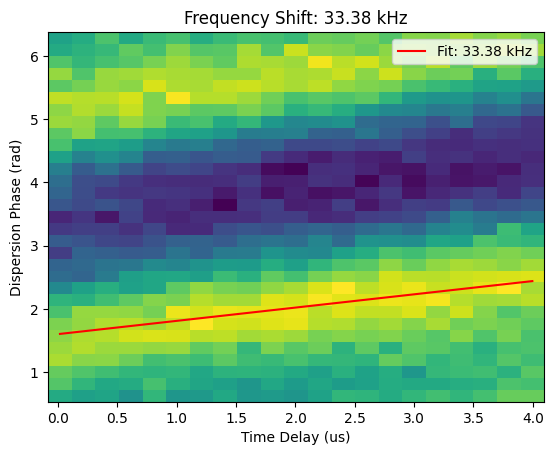

In [84]:
# 1. Perform the fit (m is in rad/us)
m, n = np.polyfit(time_delays[6:] / 1e3, disp_phase[max_indices][6:] * 2 * np.pi, 1)

# 2. Convert rad/us to kHz
# (m * 10^6 rad/s) / (2*pi rad/cycle) / 1000
slope_khz = (m * 1000) / (2 * np.pi)

print(f"Slope: {m:.4f} rad/us")
print(f"Slope: {slope_khz:.2f} kHz")

# 3. Update the Plot Title
plt.pcolormesh(time_delays / 1e3, disp_phase * 2 * np.pi, mean_intensity, shading='auto')
plt.plot(time_delays / 1e3, m * (time_delays / 1e3) + n, color='red', 
         label=f"Fit: {slope_khz:.2f} kHz")

plt.xlabel("Time Delay (us)")
plt.ylabel("Dispersion Phase (rad)")
plt.title(f"Frequency Shift: {slope_khz:.2f} kHz")
plt.legend()
plt.show()